Assignment 1 Homework :)

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pickle
import pandas as pd
from unittest.mock import patch
import requests
from bs4 import BeautifulSoup
import re
import time
import random


Question 1:

In [3]:
G = nx.DiGraph()
with open('data/polblogs_nodes_class.tsv', 'r') as fp:
    for line in fp:
        node_id, node_label, node_political = line.strip().split('\t')
        political_orientation = 'liberal' if node_political == '0' else 'conservative'
        G.add_node(node_id, website=node_label, political_orientation=political_orientation)

In [4]:
with open('data/polblogs_edges_class.tsv','r') as fp:
    for line in fp:
        source_node_id, target_node_id = line.strip().split('\t')
        G.add_edge(source_node_id, target_node_id)

Q1 part A

In [6]:
results = {}

#EDGE LIST

#save
nx.write_edgelist(G, 'polblogs.edgelist')
#load
G_back_edgelist = nx.read_edgelist('polblogs.edgelist', #create_using=nx.DiGraph
                                   )

#results
results["Edge List"] = {
  "File Size (KB)" : round(os.path.getsize('polblogs.edgelist') / 1024, 2),
  "Nodes": G_back_edgelist.number_of_nodes(),
  "Edges": G_back_edgelist.number_of_edges(),
  "Directed?": G_back_edgelist.is_directed(),
  "Attributes?":  any('website' in data for _, data in G_back_edgelist.nodes(data=True)),
  "Perf Equal?": nx.utils.graphs_equal(G, G_back_edgelist)

}

#GRAPHML

#save
nx.write_graphml(G, 'polblogs.graphml')
#load
G_back_graphml = nx.read_graphml('polblogs.graphml')

#results
results["GraphML"] = {
  "File Size (KB)" : round(os.path.getsize('polblogs.graphml') / 1024, 2),
  "Nodes": G_back_graphml.number_of_nodes(),
  "Edges": G_back_graphml.number_of_edges(),
  "Directed?": G_back_graphml.is_directed(),
  "Attributes?":  any('website' in data for _, data in G_back_graphml.nodes(data=True)),
  "Perf Equal?": nx.utils.graphs_equal(G, G_back_graphml)

}


#JSON

#save
data_json = nx.node_link_data(G)
with open("polblogs.json", "w") as fp:
  json.dump(data_json, fp)
#load
with open("polblogs.json", "r") as fp:
  data_json = json.load(fp)
G_back_json = nx.node_link_graph(data_json)

#results
results["JSON"] = {
  "File Size (KB)" : round(os.path.getsize('polblogs.json') / 1024, 2),
  "Nodes": G_back_json.number_of_nodes(),
  "Edges": G_back_json.number_of_edges(),
  "Directed?": G_back_json.is_directed(),
  "Attributes?":  any('website' in data for _, data in G_back_json.nodes(data=True)),
  "Perf Equal?": nx.utils.graphs_equal(G, G_back_json)

}


#PICKLE

#save
with open("polblogs.pkl", "wb") as fp:
  pickle.dump(G,fp)
#load
with open("polblogs.pkl", "rb") as fp:
  G_back_pickle = pickle.load(fp)

#results
results["Pickle"] = {
  "File Size (KB)" : round(os.path.getsize('polblogs.pkl') / 1024, 2),
  "Nodes": G_back_pickle.number_of_nodes(),
  "Edges": G_back_pickle.number_of_edges(),
  "Directed?": G_back_pickle.is_directed(),
  "Attributes?":  any('website' in data for _, data in G_back_pickle.nodes(data=True)),
  "Perf Equal?": nx.utils.graphs_equal(G, G_back_pickle)

}


#DENSE ADJ MATRIX

#save
matrix = nx.to_numpy_array(G)
np.save("polblogs.npy", matrix)
#load
matrix_back = np.load("polblogs.npy")
G_back_matrix = nx.from_numpy_array(matrix_back, #create_using=nx.DiGraph
                                    )

#results
results["Dense Adjacency Matrix"] = {
  "File Size (KB)" : round(os.path.getsize('polblogs.npy') / 1024, 2),
  "Nodes": G_back_matrix.number_of_nodes(),
  "Edges": G_back_matrix.number_of_edges(),
  "Directed?": G_back_matrix.is_directed(),
  "Attributes?":  any('website' in data for _, data in G_back_matrix.nodes(data=True)),
  "Perf Equal?": nx.utils.graphs_equal(G, G_back_matrix)

}



In [7]:
df = pd.DataFrame(results).T
display(df)
#TODO: why is it being annoying, just display nicely plz
#fixed it ;)))

,File Size (KB),Nodes,Edges,Directed?,Attributes?,Perf Equal?
Edge List,213.58,1224,16718,False,False,False
GraphML,795.55,1490,19025,True,True,False
JSON,810.51,1490,19025,True,True,True
Pickle,448.64,1490,19025,True,True,True
Dense Adjacency Matrix,17344.66,1490,16718,False,False,False


Q1 part B

EDGELIST INVESTIGATION

In [ ]:
#find out wich nodes are missing

orig_nodes = set(G.nodes())
back_nodes = set(G_back_edgelist.nodes())

print('In orig but not in reload:', list(orig_nodes - back_nodes)[:10])
print('In reload but not in orig:', list(back_nodes - orig_nodes)[:10])

#check types
print(type(list(orig_nodes)[0]), type(list(back_nodes)[0]))

#edgelist has ~200 missing nodes, check is they are isolated:
missing = orig_nodes - back_nodes
for n in list(missing)[:10]:
    print(n, G.in_degree(n), G.out_degree(n))


#Compare attribute dicts on a shared node:

n = next(iter(orig_nodes and back_nodes))
print('orig:', G.nodes[n])
print('reloded:', G_back_edgelist.nodes[n])

#check if atteributes are in raw file
with open('polblogs.edgelist') as f:
  for _ in range(5):
    print(f.readline())


In orig but not in reload: ['852', '1451', '3', '922', '831', '457', '733', '230', '1283', '145']
In reload but not in orig: []
<class 'str'> <class 'str'>
852 0 0
1451 0 0
3 0 0
922 0 0
831 0 0
457 0 0
733 0 0
230 0 0
1283 0 0
145 0 0
orig: {'website': 'anothervrwc.blogspot.com', 'political_orientation': 'conservative'}
reloded: {}
0 22 {}

0 54 {}

0 84 {}

0 154 {}

0 322 {}



Edgelist appears to not keep isolated vertices(makes sense since we are only looking as the Edge List and an isolated vertex will have no edges (wower)). From the final print statment we can see that we have the format of (start node) (end node) {edge attribute} , there is no node data in the edge list format (wowzzzzer). this is a save side error.

JSON INVESTIGATION / PICKLE INVESTIGATION (not needed these guys are chill <3)

DENSE ADJ MATRIX INVESTIGATION

In [ ]:
orig_nodes = set(G.nodes())
back_nodes = set(G_back_matrix.nodes())

print("In orig but not in reload:", list(orig_nodes - back_nodes)[:10])
print("In reload but not in orig:", list(back_nodes - orig_nodes)[:10])
#wat the frik

#check types
print(type(list(orig_nodes)[0]), type(list(back_nodes)[0]))
#okay i see

n = list(G_back_matrix.nodes())[0]
print(G_back_matrix.nodes[n])
#numpy array has no way to store the node data




In orig but not in reload: ['104', '413', '230', '965', '145', '92', '154', '168', '1360', '1487']
In reload but not in orig: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<class 'str'> <class 'int'>
{}


The Attrs? coulmn is false in the table because the numpy arry does not store the nodes meta data. When we use "to_numpy_array" we convert the string ID's to matrix indices that are never used (save-side error) .

Q1 Part C

Now fix what you can by passing non-default arguments to the networkx functions.

Which arguments did you use, and what did they fix?
What can’t be fixed this way, and why?
If a fix needs information that isn’t in the file, say where that information came from.

EDGELIST:
The onlt relevent argument for edgelist is "create_using = nx.Digraph" since edgelist doesnt have a built in way of dealing with directed edges, but I already did that so....

Edgelist does not have a built in argument for node level data, so any nodes that are not incident to a edge , as well as any node embeddings is lost. This is a format limitation of edgelist. To restore the missing nodes/ node embeddings you need to pull from the original tsv file:
      G_back_edgelist.add_nodes_from(...)


GRAPHML:
There is no pubic behavior that can change how graphml reads <key> elements, to make graphs equal we can manually strip the keys after loading:
      del G_back_graphml.graph['node default']

DENSE ADJ MATRIX:
.npy stores a plain numeric array, the format does not allow us to add a 'label' channel. If we want to reconstruct the labels we need to seperatly save the node list (as a JSON or PKL sidefile)
We can change the argument nx.to_numpy_array(G, nodelist=list(G.nodes())) to pin down a deterministic row/colmn order. THIS DOES NOT RESTORE LABELS BUT IS HELPFUL FOR DOING SO. Then:
      mapping = dict(enummerate(nodelist))
      G_back_matrix = nx.relabel_nodes(G_back_matrix, mapping)

Q1 PART D

GRAPHML INVESTIGATION

In [ ]:
orig_nodes = set(G.nodes())
back_nodes = set(G_back_graphml.nodes())

#check types
#print(type(list(orig_nodes)[0]), type(list(back_nodes)[0]))

#Compare attribute dicts on a shared node:

n = next(iter(orig_nodes and back_nodes))
print('orig:', G.nodes[n])
print('reloded:', G_back_graphml.nodes[n])

#Check the dict key value pairs
for k,v in G.nodes[n].items():
  print(k, repr(v), type(v))

print('***')

for k,v in G_back_graphml.nodes[n].items():
  print(k,repr(v), type(v))


#chech edge attrs

e = next(iter(G.edges()))
print('orig edge data:', G.get_edge_data(*e))
print('reloaded edge data:', G_back_graphml.get_edge_data(*e))

print('orig graph attrs', G.graph)
print('reloaded graph attrs', G_back_graphml.graph)

#Check raw graphml file
#with open('polblogs.graphml') as f:
  #print(f.read(3000))

orig: {'website': 'boycottsbg.com', 'political_orientation': 'liberal'}
reloded: {'website': 'boycottsbg.com', 'political_orientation': 'liberal'}
website 'boycottsbg.com' <class 'str'>
political_orientation 'liberal' <class 'str'>
***
website 'boycottsbg.com' <class 'str'>
political_orientation 'liberal' <class 'str'>
orig edge data: {}
reloaded edge data: {}
orig graph attrs {}
reloaded graph attrs {'node_default': {}, 'edge_default': {}}


The graph level metadata is differnt (orig graph attrs vs. reloaded graph attrs). When nx.read.graphml purses through the data it reads the <key> elements( declares each attrs name/ type and an optinial sub-element <default>) and builds a internal node/ edge default dict to track default values for each decared attibute, even when there is no <default> specificed => this is where the {} comes from in our reloded graph atts and what causes return true? to be false, even tough attributes are true.

I would say that since this is just an artifact of how graphml reads the data, and there is no loss of information about the graph that this is harmless.

Q1 PART E

In [ ]:
P = nx.path_graph(5)

nx.write_edgelist(P, 'path.edgelist')
nx.write_graphml(P, 'path.graphml')

G_back_edge_default = nx.read_edgelist('path.edgelist')
G_back_graph_default = nx.read_graphml('path.graphml')

print(type(list(G_back_edge_default.nodes())[0]))
print(type(list(G_back_graph_default.nodes())[0]))

<class 'str'>
<class 'str'>


In [ ]:
#with open('polblogs.edgelist') as f:
 #   for _ in range(5):
  #      print(repr(f.readline()))

#with open('polblogs.graphml') as f:
 #   content = f.read()

# print just the <key> declarations — this is the ONLY place GraphML stores type info
#import re
#keys = re.findall(r'<key[^>]*/?>.*?</key>|<key[^>]*/>', content)
#for k in keys:
 #   print(k)

'0 22 {}\n'
'0 54 {}\n'
'0 84 {}\n'
'0 154 {}\n'
'0 322 {}\n'
<key id="d1" for="node" attr.name="political_orientation" attr.type="string"/>
<key id="d0" for="node" attr.name="website" attr.type="string"/>


They both convert int node labels to strs, to fix this we can alter the argument to :
      nx.read_edgelist('path.edgelist', nodetype = int)
      nx.read_graphml('path.graphml', nodetype = int)

There is no type tag in the data files, so a colleague would need you to inform them that the node labels are ints.

Q1 PART F and G:

The larest file size is the Dense Adj Matrix (wowzerers) and the smallest is the Edge List. This is because edge list is ONLY saving data for edges that exist. It is not storings isolated nodes, or node embeddings. JUST EDGES. Meanwhile, Dense Adj matrix is storing data (a matrix entry) for each POSSIABLE edge. Wheather or not a node is present in the graph is stored explictily in the Dense Adj Matrix whereas, it is stored implicity in the edgelist (the absence of an edges data => there is no edge). For the Dense Adj matrix we store:

$$1490 \times 1490 = 2{,}220{,}100 \text{ entries}$$

and for the edge list we only store 19,025 actual edges.

**For $10^6$ nodes with the same avg edges per node:**

$$\bar{d} = \frac{|E|}{|N|} = 12.7$$

for $10^6$ nodes:

$$12.7 = \frac{|E|}{10^6} \implies |E| = 12.7 \times 10^6$$

**EDGE LIST:**

Bytes per an edge:

$$\frac{\text{file size}}{|E|} = \frac{213.38 \times 1024}{19025} = 11.5 \text{ bytes/edge}$$

for $12.7 \times 10^6$ edges:

$$11.5 \ \frac{\text{bytes}}{\text{edge}} \times 12.7\times10^6 \text{ edges} = 11.5 \times 12.7 \times 10^6 \text{ bytes}$$

**DENSE ADJ MATRIX:**

bytes per matrix entry:

$$\frac{17{,}344.66 \times 1024}{1490^2} \approx 8 \text{ bytes/entry}$$

for $10^{6^2}$ entries:

$$8 \ \frac{\text{bytes}}{\text{entry}} \times 10^{6^2} \text{ entries} = 8 \times 10^{12} \text{ bytes} !!!!!!$$

## Q1 Part G

*One of these formats can run someone else's code on your computer when you load a file they sent you. Which one, and which line of your code is the dangerous one? Please explain the risk as simply as possible.*

```python
G_back_pickle = pickle.load(fp)
```

Pickle is not just storing data, when you use `pickle.load()`, pickle excecutes internal directions and prebuilds the object. Pickle cannot distinguish between normal instructions and malicious instructions. If a collegue sends you a `.pkl` file and you call `pickle.load()` you are practially running a program they built (not visable to you) with whatever permissions your account has. (THIS MAKES MALWARE HAPPY :))

Q3

In [8]:
def my_subgraph_cent(G, normalized = False):
  """
  Compute the subgraph centrality for every node in a SIMPLE undirected graph. SGC of a node u is defined as the su of weighted closed walks of all lengths that start and end at u.
  Longer walks are given expontialy smaller weights. This is equivilent to the u^th diagonal entry of the matrix expontial e^A.
  This implementation computes it via spectral decomposition (SC(u) = sum_j (v_{u,j}^2)*exp^(lambda_j)). Where lambda_j is the j^th eigenvalue of A and v_j is its corresponding eigenvector.
  This holds becuase A is a symmeric which implies we have a full orthonomal eigenbasis. Each eigenvecots contribution to node u is weighted by how
  stongly it participates in that eigenmode (v_{u,j}^2), scaled by e^{lambda_j}, so that eigenmodes with larger eigenvalues (denser local clustering / more local closed walks) dominates the sum.

  Parameters:
  G: NetworkX.Graph
  undirected simple graph with at least 1 node

  Normalized: bool,  default = False
  If True, divide every centrality value by exp(spectrail radius) rescaling the values between 0 and 1.


  Returns:
  sc: dict
  Dictionary mapping each node in G to its float sc value

  Raise:
  TypeError:
  If G is not a networkx.graph instance

  ValueError:
  If G has no nodes or if a numerical overflow makes the sc results unreliable.

  networkx.NetworkXError:
  If G is directed, has self-loops, or is a multigraph (much of the math still works for selfloops/ multiedges , but the MEANING behind what we are measuring becomes less clear)


  Notes:
  exp(x) never equals 0 or inf for finite x, and our spectrail radoius is guarnted to follow this. However, np.exp overflows to inf for inputs ~800. To avoid this, when normalizing we instead compute:
            exp(lambda_j - spec_rad)

  Since Lambda_j <= spectrail radius,  every expont <=0.

  """
  if not isinstance(G, nx.Graph):
    raise TypeError("Input must be a networkx graph")

  if G.number_of_nodes() == 0:
    raise ValueError("K_0 has an undefined subgraph centrality")

  if G.is_directed():
    raise nx.NetworkXError("Graph must be Undirected")

  if nx.number_of_selfloops(G) > 0:
    raise nx.NetworkXError("Graph must be SIMPLE")

  if G.is_multigraph():
    raise nx.NetworkXError("Graph must be SIMPLE")


  nodelist = list(G.nodes())
  #converting to unweighted so i can compre the karate club graphs lul
  A = nx.to_numpy_array(G, nodelist=nodelist, weight=None)

  eigenvals, eigenvecs = np.linalg.eigh(A)
  sc_vals = (eigenvecs ** 2)@np.exp(eigenvals)
  sc = {node: float(val) for node, val in zip(nodelist, sc_vals)}

  if normalized:
      spec_rad = eigenvals[-1]
      shifted = np.exp(eigenvals - spec_rad)  # always in (0, 1]
      if not np.all(np.isfinite(shifted)):
          raise ValueError(
              "Numerical overflow while normalizing "
          )
      norm_values = (eigenvecs ** 2) @ shifted
      sc = {node: float(val) for node, val in zip(nodelist, norm_values)}

  return sc


In [9]:
G_disc = nx.disjoint_union(nx.cycle_graph(4), nx.path_graph(3))

graphs = {
    "No edges (n=6)" : nx.empty_graph(6),
    "Disconnected GRaph (C4 + P3)" : G_disc,
    "Peterson Graph" : nx.petersen_graph(),
    "Complete Graph (n=6)" : nx.complete_graph(6),
    "Karate Club" : nx.karate_club_graph(),
    "Barbell Graph" : nx.barbell_graph(m1=3, m2=4)
}


def compare_centrality(my_fn, their_fn, graphs, normalized = False, tol = 1e-8):

  rows = []
  for name, G in graphs.items():
    my_sc = my_fn(G, normalized = normalized)
    their_sc = their_fn(G, normalized = normalized)

    node = list(G.nodes())
    mine_vals = np.array([my_sc[n] for n in node])
    their_vals = np.array([their_sc[n] for n in node])

    max_abs_diff = np.max(np.abs(mine_vals - their_vals))
    match = np.allclose(mine_vals, their_vals, atol=tol)

    rows.append({
        "graph": name,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "max_abs_diff": max_abs_diff,
        "match": match
      })

  return pd.DataFrame(rows)


print("===Unnormalized===")
results_raw = compare_centrality(my_subgraph_cent, nx.subgraph_centrality, graphs, normalized = False)
print(results_raw)

print("===Normalized===")
results_norm = compare_centrality(my_subgraph_cent, nx.subgraph_centrality, graphs, normalized= True)
print(results_norm)

===Unnormalized===
                          graph  n_nodes  n_edges  max_abs_diff  match
0                No edges (n=6)        6        0           0.0   True
1  Disconnected GRaph (C4 + P3)        7        6           0.0   True
2                Peterson Graph       10       15           0.0   True
3          Complete Graph (n=6)        6       15           0.0   True
4                   Karate Club       34       78           0.0   True
5                 Barbell Graph       10       11           0.0   True
===Normalized===
                          graph  n_nodes  n_edges  max_abs_diff  match
0                No edges (n=6)        6        0           0.0   True
1  Disconnected GRaph (C4 + P3)        7        6           0.0   True
2                Peterson Graph       10       15           0.0   True
3          Complete Graph (n=6)        6       15           0.0   True
4                   Karate Club       34       78           0.0   True
5                 Barbell Graph       10 

Q3 part C

Our results are identical (or nearly so) because of two main reasons.
we are working on simple unweighted , and undirected graphs. This helps ensure that we are measuring the same thing (the number of closed walks they paticipte in).Currently we both have the same gardrails implemented. BUT while testing I didnt realise I forgot to deal with the weighted network case and only noticed when seeing the comparison for the karate club graph. My implimentation specifically used eigh to find the eigenmodes so it was comletly wrong for that graph!! However, i then changed it to convert weighted graphs to normal graphs and then both our values matched again so I'm assuming they've implemented a very simular method.
Furthermore, since the SGC has a very simple (and fun) mathematical expression its very easy for us to implement the same formulas and if we're both using the same formulas on the same graphs then we should obvisouly get the same values. (All the calculations are about 3 lines of code so there not much room for rounding errors to accumulate )



Q3 Part D

In [ ]:
import warnings

def test_my_subgraph_cent():
    print("--- Error handling ---")
    error_cases = [
        ("not a graph", [1, 2, 3], TypeError),
        ("empty graph", nx.empty_graph(0), ValueError),
        ("directed graph", nx.DiGraph([(1, 2)]), nx.NetworkXError),
        ("self-loop", nx.Graph([(1, 1), (1, 2)]), nx.NetworkXError),
        ("multigraph", nx.MultiGraph([(1, 2), (1, 2)]), nx.NetworkXError),
    ]
    for name, G, err in error_cases:
        try:
            my_subgraph_cent(G)
            print(f"FAIL - {name}: no error raised")
        except err:
            print(f"PASS - {name}: raised {err.__name__} as expected")
        except Exception as e:
            print(f"FAIL - {name}: raised wrong error {type(e).__name__}")

    print("\n--- value agreement with networkx ---")
    test_graphs = {
        "empty edges": nx.empty_graph(4),
        "triangle": nx.complete_graph(3),
        "Petersen": nx.petersen_graph(),
        "disconnected": nx.disjoint_union(nx.cycle_graph(3), nx.path_graph(3)),
        "star": nx.star_graph(5),
        "karate club": nx.karate_club_graph(),
    }
    for name, G in test_graphs.items():
        for normalized in [False, True]:
            mine = my_subgraph_cent(G, normalized=normalized)
            theirs = nx.subgraph_centrality(G, normalized=normalized)
            match = all(np.isclose(mine[n], theirs[n]) for n in G.nodes())
            tag = "normalized" if normalized else "unnormalized"
            print(f"{'PASS' if match else 'FAIL'} - {name} ({tag})")
            for n in G.nodes():
                print(f"    node {n}: mine={mine[n]:.4f}  networkx={theirs[n]:.4f}")

    print("\n--- Overflow behavior on a large dense graph (K_750) ---")
    G_dense = nx.complete_graph(750)
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        mine_unnorm = my_subgraph_cent(G_dense, normalized=False)
        my_overflowed = any("overflow" in str(x.message) for x in w)

    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        theirs_unnorm = nx.subgraph_centrality(G_dense, normalized=False)
        nx_overflowed = any("overflow" in str(x.message) for x in w)

    print(f"my_subgraph_cent overflowed: {my_overflowed}")
    print(f"nx.subgraph_centrality overflowed: {nx_overflowed}")
    print("Both overflow identically:", my_overflowed == nx_overflowed == True)

    # Normalized version should NOT overflow, thanks to the shift trick
    mine_norm = my_subgraph_cent(G_dense, normalized=True)
    all_finite = np.all(np.isfinite(list(mine_norm.values())))
    print(f"PASS - normalized K_750 stays finite (shift trick works): {all_finite}"
          if all_finite else "FAIL - normalized K_750 produced inf/nan")

    with warnings.catch_warnings(record=True) as w2:
        warnings.simplefilter("always")
        theirs_norm = nx.subgraph_centrality(G_dense, normalized=True)
        theirs_norm_overflowed = any("overflow" in str(x.message) for x in w2)

    theirs_norm_finite = np.all(np.isfinite(list(theirs_norm.values())))
    print(f"nx.subgraph_centrality (normalized) overflowed: {theirs_norm_overflowed}")
    print(f"nx.subgraph_centrality (normalized) all finite: {theirs_norm_finite}")

test_my_subgraph_cent()

--- Error handling ---
PASS - not a graph: raised TypeError as expected
PASS - empty graph: raised ValueError as expected
PASS - directed graph: raised NetworkXError as expected
PASS - self-loop: raised NetworkXError as expected
PASS - multigraph: raised NetworkXError as expected

--- value agreement with networkx ---
PASS - empty edges (unnormalized)
    node 0: mine=1.0000  networkx=1.0000
    node 1: mine=1.0000  networkx=1.0000
    node 2: mine=1.0000  networkx=1.0000
    node 3: mine=1.0000  networkx=1.0000
PASS - empty edges (normalized)
    node 0: mine=1.0000  networkx=1.0000
    node 1: mine=1.0000  networkx=1.0000
    node 2: mine=1.0000  networkx=1.0000
    node 3: mine=1.0000  networkx=1.0000
PASS - triangle (unnormalized)
    node 0: mine=2.7083  networkx=2.7083
    node 1: mine=2.7083  networkx=2.7083
    node 2: mine=2.7083  networkx=2.7083
PASS - triangle (normalized)
    node 0: mine=0.3665  networkx=0.3665
    node 1: mine=0.3665  networkx=0.3665
    node 2: mine=0.36

/tmp/ipykernel_1570/3338406884.py:60: RuntimeWarning: overflow encountered in exp
  sc_vals = (eigenvecs ** 2)@np.exp(eigenvals)


PASS - normalized K_750 stays finite (shift trick works): True
nx.subgraph_centrality (normalized) overflowed: False
nx.subgraph_centrality (normalized) all finite: True


I did several test cases. For the first section, I wanted to make sure my error cases rasied correctely so I choose the following:
        ("not a graph", [1, 2, 3], TypeError),
        ("empty graph", nx.empty_graph(0), ValueError),
        ("directed graph", nx.DiGraph([(1, 2)]), nx.NetworkXError),
        ("self-loop", nx.Graph([(1, 1), (1, 2)]), nx.NetworkXError),
        ("multigraph", nx.MultiGraph([(1, 2), (1, 2)]), nx.NetworkXError),
I wanted to make the 'graphs' small / simle as possiable so that i could be sure it was correctly identifying the errors. (and im lazy).

For the next section I was just double checking that my answers alligned with the networkx implimentation. Because if they dont match, that would be a sign there is an issue with my code. Either in how its filtering graphs or how its calculating the spectrail decomp. I choose the empty graph because I can hand compute the values and easliy verify everything works, it also makes for a good error handling case. Triangle and Peterson are both regular graphs so I expect to see each node having the same score. For the disconnected graph, I wanted to do edge case testing , but i also wanted to compare the u_i values since I know that spec_rad(C3) = spec_rad(C_3 + P_3) = 2. In the norm vecors for both graphs I can see that the u_i values for the triangle are actualy the same! WIE CUUL IS DAS!! Which logically makes sence becuase of what Subgraph centrality is measuring. I wanted to use the star graph to 1) compare it to the regular graphs 2) make sure my intution as right (that all the leaf nodes will have the same score) Finally I use the Karate clube because I wanted a graph that was more irregular than all the other ones. I also though it would be an intresting way to "measure" who is present in the most "sub communites" in the network, maybe someone who isnt the most popular but the most agreeable?

        "empty edges": nx.empty_graph(4),
        "triangle": nx.complete_graph(3),
        "Petersen": nx.petersen_graph(),
        "disconnected": nx.disjoint_union(nx.cycle_graph(3), nx.path_graph(3)),
        "star": nx.star_graph(5),
        "karate club": nx.karate_club_graph(),

For the final section I wanted to test the case for when e^lambda causes an overflow. Clearly for both my implentation and networkx's implentation it overflows for the unnormalized case, and (after checking their docs) we both use a simular methdod for dealing with the overflow in the normalized case. I think people should (almost) always use the normalized score (with everything not just subgraph centrality). Not only does the subgraph centrality score become uncomputable for most graphs with a large spectral radius, but also it gives less meaning to the score. It's impossiable for anyone to truly intrpret the unnormalized score because the number will be arbituraly large/small for large/small graphs. The normalized score makes for a more intutive (and computationaly safer) metric as comparision can be made not only between nodes of a graph but between different graphs. However, one should note that for  e^x as x->-inf the values will get increadly tiny. This is the correct behavior and shouldnt cause diviion by 0 for finite graphs. But values could get so small that rounding leads to them being 0 even though that is not possiable. Imagine a densily connected core and a long path, The final node in the path will only participe in one subgraph, and the dense core wil have alot, meaning that this node is (almost) compleatly irrelivent to the subgraph structure of this graph. :(  

The bellow is not my work, but i just wanted to see what the results would look like. IT is not used for my comparisons or analysis!!!!


Petersen Graph  (n=10, m=15)
Eigenvalues (ascending):
[-2. -2. -2. -2.  1.  1.  1.  1.  1.  3.]

Spectral radius (lambda_max): 3.0000

Subgraph centrality (unnormalized), most -> least central:
  node 2: 3.4218   (normalized: 0.1704)
  node 0: 3.4218   (normalized: 0.1704)
  node 6: 3.4218   (normalized: 0.1704)
  node 1: 3.4218   (normalized: 0.1704)
  node 8: 3.4218   (normalized: 0.1704)
  node 9: 3.4218   (normalized: 0.1704)
  node 4: 3.4218   (normalized: 0.1704)
  node 3: 3.4218   (normalized: 0.1704)
  node 5: 3.4218   (normalized: 0.1704)
  node 7: 3.4218   (normalized: 0.1704)

Most central node(s): [2, 0, 6, 1, 8, 9, 4, 3, 5, 7]  (value = 3.4218)


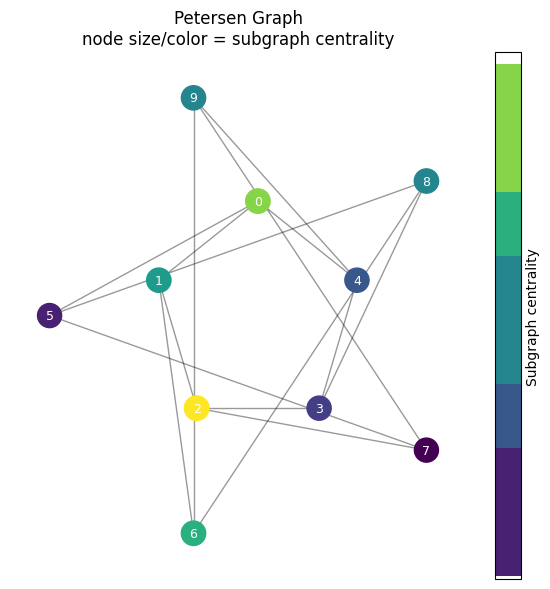


Barbell Graph (m1=3, m2=4)  (n=10, m=11)
Eigenvalues (ascending):
[-1.9122 -1.5962 -1.     -1.     -1.     -0.1826  0.7135  1.5157  2.1987
  2.2631]

Spectral radius (lambda_max): 2.2631

Subgraph centrality (unnormalized), most -> least central:
  node 7: 3.5472   (normalized: 0.3690)
  node 2: 3.5472   (normalized: 0.3690)
  node 0: 2.7851   (normalized: 0.2897)
  node 1: 2.7851   (normalized: 0.2897)
  node 8: 2.7851   (normalized: 0.2897)
  node 9: 2.7851   (normalized: 0.2897)
  node 6: 2.3543   (normalized: 0.2449)
  node 3: 2.3543   (normalized: 0.2449)
  node 5: 2.2817   (normalized: 0.2374)
  node 4: 2.2817   (normalized: 0.2374)

Most central node(s): [7, 2]  (value = 3.5472)


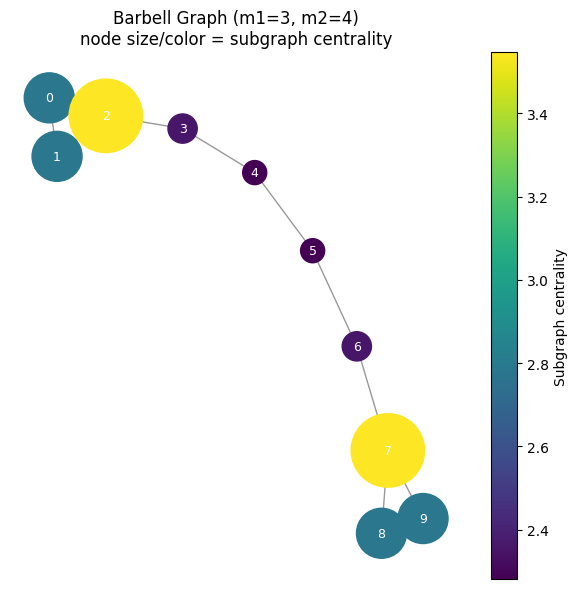

In [ ]:

def analyze_graph(G, name, sc_fn=my_subgraph_cent, layout_seed=42, layout=None):
    print(f"\n{'='*50}")
    print(f"{name}  (n={G.number_of_nodes()}, m={G.number_of_edges()})")
    print(f"{'='*50}")

    # --- eigen-info ---
    nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist, weight=None)
    eigenvalues = np.linalg.eigvalsh(A)  # ascending order
    spectral_radius = eigenvalues[-1]

    print("Eigenvalues (ascending):")
    print(np.round(eigenvalues, 4))
    print(f"\nSpectral radius (lambda_max): {spectral_radius:.4f}")

    # --- subgraph centrality ---
    sc = sc_fn(G, normalized=False)
    sc_norm = sc_fn(G, normalized=True)

    # sort nodes by centrality, descending
    ranked = sorted(sc.items(), key=lambda kv: kv[1], reverse=True)

    print("\nSubgraph centrality (unnormalized), most -> least central:")
    for node, val in ranked:
        print(f"  node {node}: {val:.4f}   (normalized: {sc_norm[node]:.4f})")

    top_val = ranked[0][1]
    top_nodes = [n for n, v in ranked if np.isclose(v, top_val, atol=1e-6)]
    print(f"\nMost central node(s): {top_nodes}  (value = {top_val:.4f})")

    # --- draw graph, node size/color scaled by centrality ---
    #pos = nx.spring_layout(G, seed=layout_seed)
    if layout is not None:
      pos = layout(G)
    else:
      pos = nx.spring_layout(G, seed=layout_seed)
    values = np.array([sc[n] for n in nodelist])

    # scale node size for visibility
    sizes = 300 + 2500 * (values - values.min()) / (values.max() - values.min() + 1e-12)

    plt.figure(figsize=(6, 6))
    nodes_drawn = nx.draw_networkx_nodes(
        G, pos, nodelist=nodelist, node_size=sizes,
        node_color=values, cmap=plt.cm.viridis
    )
    nx.draw_networkx_edges(G, pos, alpha=0.4)
    nx.draw_networkx_labels(G, pos, font_color="white", font_size=9)
    plt.colorbar(nodes_drawn, label="Subgraph centrality")
    plt.title(f"{name}\nnode size/color = subgraph centrality")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return sc, sc_norm, eigenvalues


sc_pete, sc_pete_norm, eig_pete = analyze_graph(
    nx.petersen_graph(),
    "Petersen Graph",
    layout=lambda G: nx.shell_layout(G, nlist=[range(5), range(5, 10)])
)

sc_bar, sc_bar_norm, eig_bar = analyze_graph(
    nx.barbell_graph(m1=3, m2=4),
    "Barbell Graph (m1=3, m2=4)"
)

Q4

In [10]:
BASE_URL = 'https://catalog.northeastern.edu'
SAVE_DIR = 'dept_htmls'

In [11]:
#SCRAPER FOR ONE DEPT
def clean(s):
    """Collapse nbsp/tabs/multiple spaces into single spaces."""
    return re.sub(r'\s+', ' ', s).strip()

def get_course_prereqs(dept_html):
    """
    Return {course_code: [linked prerequisite codes]} for every course on a
    department page, including courses with no prerequisites (empty list).
    """
    soup = BeautifulSoup(dept_html, 'html.parser')
    result = {}

    for block in soup.find_all('div', class_='courseblock'):
        title = block.find('p', class_='courseblocktitle')
        if not title:
            continue
        course_code = clean(title.get_text().split('.')[0])

        prereqs = []
        for p in block.find_all('p', class_='courseblockextra'):
            if 'Prerequisite' in p.get_text():
                for link in p.find_all('a', class_='bubblelink code'):
                    prereqs.append(clean(link.get_text()))

        result[course_code] = list(dict.fromkeys(prereqs))  # dedupe, keep order

    return result

# quick test on one department
test_html = requests.get(BASE_URL + '/course-descriptions/eemb/').text
print(get_course_prereqs(test_html))

{'EEMB 1101': [], 'EEMB 1102': [], 'EEMB 1105': [], 'EEMB 1106': [], 'EEMB 1990': [], 'EEMB 2302': ['ENGW 1111', 'ENGW 1102'], 'EEMB 2303': [], 'EEMB 2400': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'ENVR 1400'], 'EEMB 2610': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'EEMB 1105', 'ENVR 1400'], 'EEMB 2700': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'ENGW 1111', 'ENGW 1102'], 'EEMB 2701': [], 'EEMB 2990': [], 'EEMB 3451': ['BIOL 1113', 'BIOL 2299', 'EEMB 1101'], 'EEMB 3455': ['BIOL 1107', 'BIOL 1111', 'CHEM 1161', 'CHEM 1214', 'EEMB 2302', 'ENVR 1200', 'ENVR 2200'], 'EEMB 3460': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'EEMB 2302', 'ENVR 1101', 'ENVR 1400'], 'EEMB 3465': ['BIOL 2301', 'ECON 2350', 'EEMB 2400', 'ENVR 2500', 'MATH 3081'], 'EEMB 3466': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'EEMB 2302'], 'EEMB 3475': ['EEMB 2302'], 'EEMB 3600': ['BIOL 1113', 'BIOL 2299', 'EEMB 1105'], 'EEMB 3990': [], 'EEMB 4000': [], 'EEMB 4001': ['BIOL 1107', 'BIOL 1111', 'EEMB 1101', 'ENVR 1101', 'ENVR 1400'],

In [12]:
#CATALOG SCRAPER AND GRAPH BUILDER
def get_department_hrefs():
    html = requests.get(BASE_URL + '/course-descriptions/').text
    soup = BeautifulSoup(html, 'html.parser')
    hrefs = []
    for ul in soup.find('div', id='atozindex').find_all('ul'):
        for li in ul.find_all('li'):
            hrefs.append(li.a.get('href'))
    return hrefs

def download_departments(hrefs, save_dir=SAVE_DIR):
    os.makedirs(save_dir, exist_ok=True)
    for i, href in enumerate(hrefs, 1):
        name = href.strip('/').split('/')[-1]
        path = os.path.join(save_dir, f'{name}.html')
        if os.path.exists(path):
            continue                      # already cached, no request, no pause
        try:
            print(f'({i}/{len(hrefs)}) downloading {name}')
            r = requests.get(BASE_URL + href)
            with open(path, 'w', encoding='utf-8') as f:
                f.write(r.text)
            time.sleep(1)
        except Exception as e:
            print(f'Error on {name}: {e}')

def build_graph(save_dir=SAVE_DIR):
    """Edges point prerequisite -> course. in_catalog=True marks real catalog courses."""
    G = nx.DiGraph()
    for fname in os.listdir(save_dir):
        if not fname.endswith('.html'):
            continue
        with open(os.path.join(save_dir, fname), encoding='utf-8') as f:
            courses = get_course_prereqs(f.read())
        for course, prereqs in courses.items():
            G.add_node(course, in_catalog=True)   # every course is a node
            for p in prereqs:
                G.add_edge(p, course)             # creates prereq node if new
    return G

department_hrefs = get_department_hrefs()
print(len(department_hrefs), 'departments')
download_departments(department_hrefs)
print(len(os.listdir(SAVE_DIR)), 'files cached')

G = build_graph()

227 departments
(1/227) downloading acct
(2/227) downloading acc
(3/227) downloading avm
(4/227) downloading afcs
(5/227) downloading amsl
(6/227) downloading aly
(7/227) downloading anth
(8/227) downloading ant
(9/227) downloading aai
(10/227) downloading apl
(11/227) downloading arab
(12/227) downloading arch
(13/227) downloading army
(14/227) downloading art
(15/227) downloading artg
(16/227) downloading artf
(17/227) downloading arte
(18/227) downloading arth
(19/227) downloading artd
(20/227) downloading aace
(21/227) downloading arts
(22/227) downloading asns
(23/227) downloading bnsc
(24/227) downloading bioc
(25/227) downloading bioe
(26/227) downloading binf
(27/227) downloading biol
(28/227) downloading bio
(29/227) downloading biot
(30/227) downloading btc
(31/227) downloading busn
(32/227) downloading exsc
(33/227) downloading chme
(34/227) downloading chem
(35/227) downloading chm
(36/227) downloading chns
(37/227) downloading cive
(38/227) downloading ced
(39/227) downloa

In [13]:
#SAITY CHECKS
def graph_summary(G, name='G'):
    in_cat = [n for n, d in G.nodes(data=True) if d.get('in_catalog')]
    outside = [n for n in G.nodes if n not in set(in_cat)]
    print(f'--- {name} ---')
    print('Nodes:', G.number_of_nodes(), '| Edges:', G.number_of_edges())
    print('Catalog courses:', len(in_cat), '| Nodes not in catalog:', len(outside))
    print('Courses with no prerequisites:', sum(1 for n in in_cat if G.in_degree(n) == 0))
    print('Self-loops:', nx.number_of_selfloops(G))
    print('Is DAG:', nx.is_directed_acyclic_graph(G))
    print('Sample outside-catalog nodes:', outside[:10])

graph_summary(G, 'G')

--- G ---
Nodes: 7813 | Edges: 5680
Catalog courses: 7812 | Nodes not in catalog: 1
Courses with no prerequisites: 5333
Self-loops: 6
Is DAG: False
Sample outside-catalog nodes: ['MIS 6100']


Most prerequisites (high in-degree): [('ECON 2560', 20), ('NRSG 2222', 14), ('SOCL 4522', 14), ('PSYC 4678', 14), ('HSCI 4700', 13), ('PHTH 4202', 13), ('DADS 7305', 13), ('NRSG 4610', 12), ('NRSG 2220', 11), ('BIOC 4971', 11)]
Most often required (high out-degree): [('ENGW 1111', 232), ('ENGW 1102', 232), ('ENGW 1114', 194), ('MATH 2341', 45), ('MATH 3081', 45), ('MGSC 2301', 44), ('PSYC 2320', 41), ('POLS 1160', 41), ('MATH 2321', 39), ('SOCL 1101', 35)]


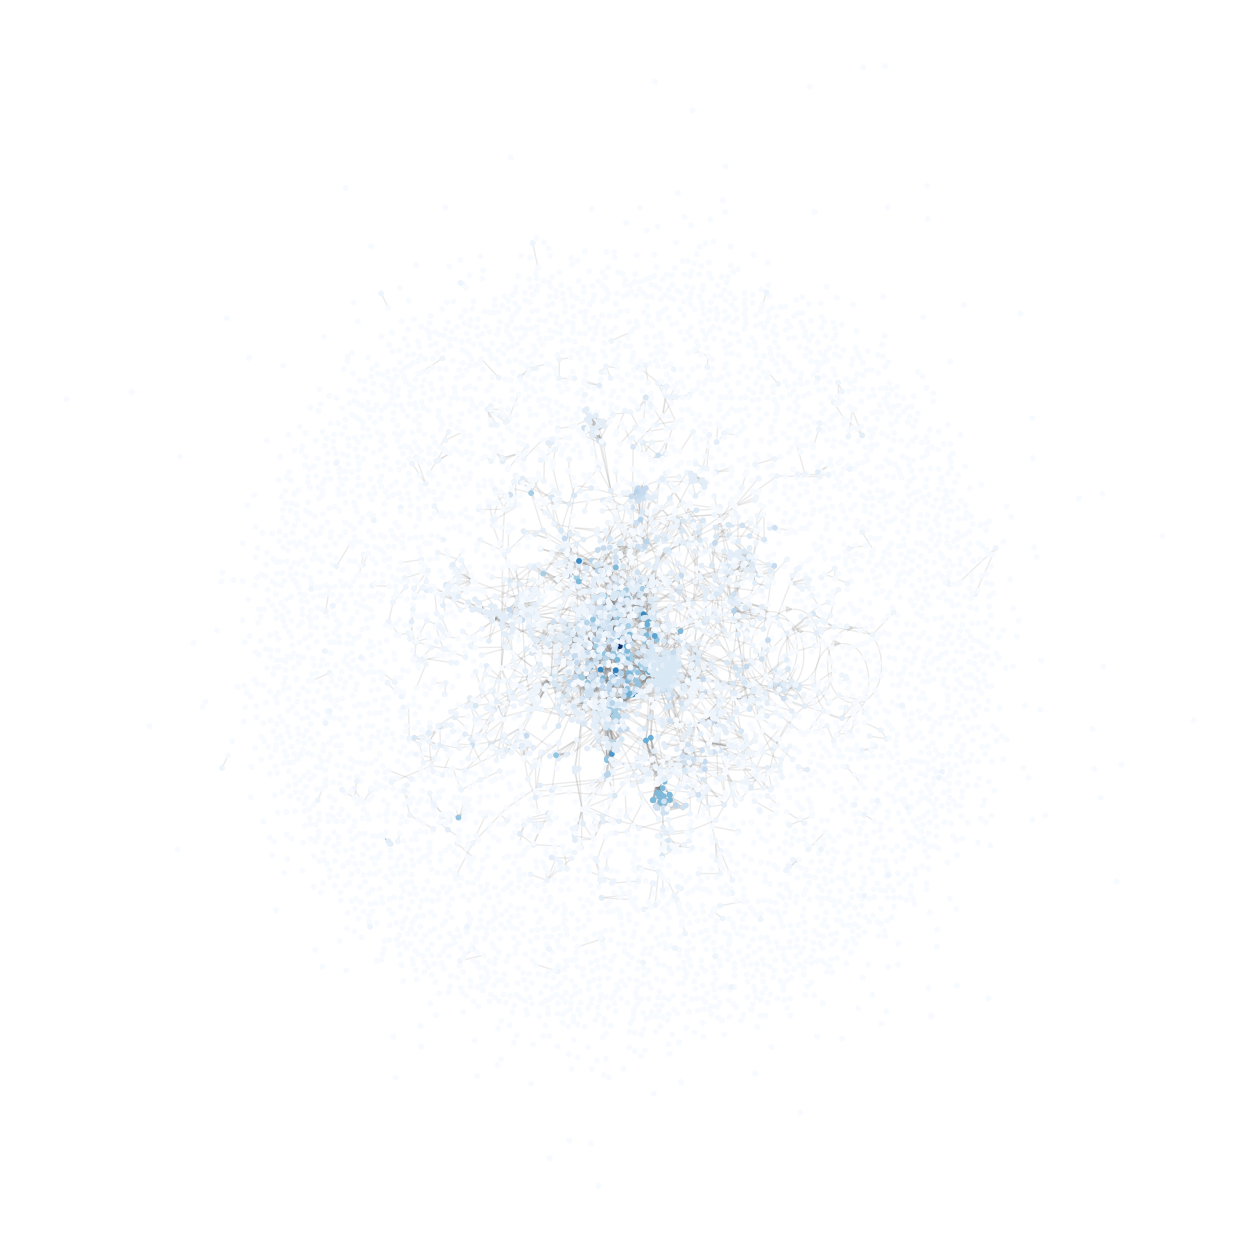

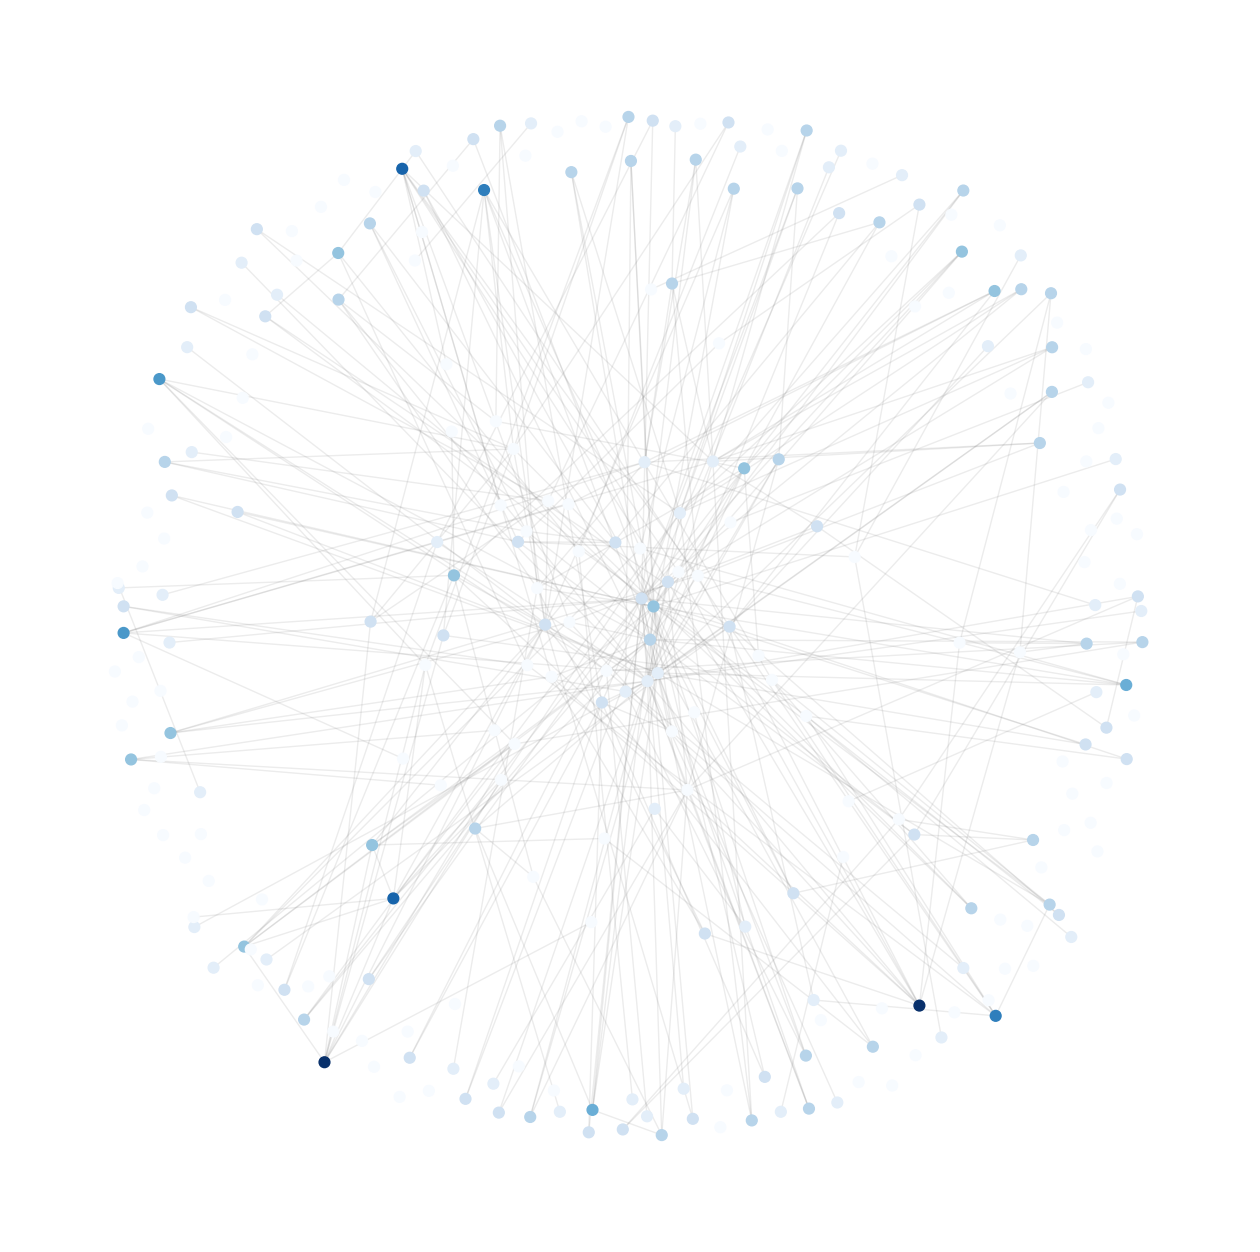

In [14]:
#DEG STATS AND VIS
def degree_report(G, k=10):
    ind, outd = dict(G.in_degree()), dict(G.out_degree())
    print('Most prerequisites (high in-degree):',
          sorted(ind.items(), key=lambda x: -x[1])[:k])
    print('Most often required (high out-degree):',
          sorted(outd.items(), key=lambda x: -x[1])[:k])

degree_report(G)

def plot_graph(G, nodes=None, fname=None, node_size=10):
    H = G.subgraph(nodes) if nodes is not None else G
    plt.figure(figsize=(16, 16))
    pos = nx.spring_layout(H, k=0.3, iterations=50, seed=0)
    colors = [H.in_degree(n) for n in H.nodes]
    nx.draw_networkx_nodes(H, pos, node_color=colors, cmap=plt.cm.Blues, node_size=node_size)
    nx.draw_networkx_edges(H, pos, edge_color='gray', arrows=False, alpha=0.15)
    plt.axis('off')
    if fname:
        plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()

plot_graph(G, fname='full_graph.png')

# Easier to read: one department plus its direct neighbors
def dept_nodes(G, dept):
    core = [n for n in G if n.split()[0] == dept]
    nbrs = set(core)
    for n in core:
        nbrs |= set(G.predecessors(n)) | set(G.successors(n))
    return nbrs

plot_graph(G, nodes=dept_nodes(G, 'CS'), node_size=60)

In [15]:
#AVG PREREQS BY DEPT
def dept_prereq_table(G, min_courses=10):
    rows = [(n.split()[0], G.in_degree(n))
            for n, d in G.nodes(data=True) if d.get('in_catalog')]
    df = pd.DataFrame(rows, columns=['dept', 'n_prereqs'])
    t = (df.groupby('dept')['n_prereqs']
           .agg(avg_prereqs='mean', n_courses='count')
           .sort_values('avg_prereqs', ascending=False))
    return t, t[t.n_courses >= min_courses]

all_G, big_G = dept_prereq_table(G)
print('G, all departments:\n', all_G.head(10))
print('\nG, departments with >= 10 courses:\n', big_G.head(10))

G, all departments:
       avg_prereqs  n_courses
dept                        
ANTH     2.685714         35
ORGB     2.500000          8
PSYC     2.276596         94
CRWT     1.958333         24
LS       1.833333         24
ENGL     1.827273        110
MUST     1.727273         22
BIOC     1.727273         11
ECON     1.681818        110
ENGW     1.666667         18

G, departments with >= 10 courses:
       avg_prereqs  n_courses
dept                        
ANTH     2.685714         35
ORGB     2.500000          8
PSYC     2.276596         94
CRWT     1.958333         24
LS       1.833333         24
ENGL     1.827273        110
MUST     1.727273         22
BIOC     1.727273         11
ECON     1.681818        110
ENGW     1.666667         18


In [16]:
#DAG CHECKS AND LONGEST PATHs
# 1. Is it a DAG, and what are the cycles?
graph_summary(G, 'G')
cycles = list(nx.simple_cycles(G))
print(len(cycles), 'cycles')
for c in sorted(cycles, key=len):
    print(' -> '.join(c + [c[0]]))

# 2. Look up what the catalog says for the courses involved
def prereq_text(course):
    path = os.path.join(SAVE_DIR, course.split()[0].lower() + '.html')
    with open(path, encoding='utf-8') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')
    for block in soup.find_all('div', class_='courseblock'):
        t = block.find('p', class_='courseblocktitle')
        if t and clean(t.get_text().split('.')[0]) == course:
            extras = [clean(p.get_text()) for p in block.find_all('p', class_='courseblockextra')]
            return clean(t.get_text()), extras
    return None

for course in sorted({c for cyc in cycles for c in cyc}):
    print(prereq_text(course), '\n')

# 3. Make it acyclic
def make_acyclic(G):
    A = G.copy()
    A.remove_edges_from(list(nx.selfloop_edges(A)))
    removed = []
    for scc in nx.strongly_connected_components(A.copy()):
        if len(scc) > 1:
            edges = list(A.subgraph(scc).edges())
            removed.extend(edges)
            A.remove_edges_from(edges)
    return A, removed

G_acyclic, removed = make_acyclic(G)
print('Removed non-self-loop edges:', removed)
graph_summary(G_acyclic, 'G_acyclic')

# 4. Longest chain
path = nx.dag_longest_path(G_acyclic)
print(len(path), 'courses,', len(path) - 1, 'steps:')
print(' -> '.join(path))

--- G ---
Nodes: 7813 | Edges: 5680
Catalog courses: 7812 | Nodes not in catalog: 1
Courses with no prerequisites: 5333
Self-loops: 6
Is DAG: False
Sample outside-catalog nodes: ['MIS 6100']
8 cycles
SPNS 1101 -> SPNS 1101
SPNS 1102 -> SPNS 1102
SPNS 2101 -> SPNS 2101
SPNS 2102 -> SPNS 2102
SPNS 3101 -> SPNS 3101
SPNS 3102 -> SPNS 3102
EDU 7150 -> EDU 7140 -> EDU 7150
SPNS 3603 -> SPNS 3602 -> SPNS 3603
('EDU 7140. Advanced Qualitative Research Methods. (3 Hours)', ['Prerequisite(s): (EDU 7100 with a minimum grade of C- ; EDU 7130 with a minimum grade of C- ); EDU 7150 with a minimum grade of C- or (EDU 7207 with a minimum grade of C- ; EDU 7218 with a minimum grade of C- ; EDU 7225 with a minimum grade of C- )']) 

('EDU 7150. Quantitative Research Methods. (3 Hours)', ['Prerequisite(s): (EDU 7130 with a minimum grade of C- ; EDU 7140 with a minimum grade of C- ) or (EDU 7207 with a minimum grade of C- ; EDU 7218 with a minimum grade of C- ; EDU 7219 with a minimum grade of C- ; EDU 7

In [17]:
# RE_EVAL PART C
all_A, big_A = dept_prereq_table(G_acyclic)

compare = (big_G.head(10)[['avg_prereqs']]
           .join(big_A[['avg_prereqs']], lsuffix='_G', rsuffix='_acyclic', how='outer'))
print(compare.sort_values('avg_prereqs_G', ascending=False))
print('Top dept in G:', big_G.index[0], '| Top dept in G_acyclic:', big_A.index[0])

      avg_prereqs_G  avg_prereqs_acyclic
dept                                    
ANTH       2.685714             2.685714
ORGB       2.500000             2.500000
PSYC       2.276596             2.276596
CRWT       1.958333             1.958333
LS         1.833333             1.833333
...             ...                  ...
TCC             NaN             0.142857
TELE            NaN             0.333333
TELR            NaN             0.272727
THTR            NaN             0.206349
WMNS            NaN             0.325000

[226 rows x 2 columns]
Top dept in G: ANTH | Top dept in G_acyclic: ANTH


In [18]:
#OR CHAINS?
for a, b in zip(path, path[1:]):
    title, extras = prereq_text(b)
    line = next((e for e in extras if e.startswith('Prerequisite')), '')
    print(f"{a} -> {b}")
    print(f"   {line}")
    print(f"   has 'or' alternatives: {' or ' in line}\n")

MATH 1231 -> MATH 1242
   Prerequisite(s): MATH 1231 with a minimum grade of D- or MATH 21BM with a minimum grade of D- or MATH 1241 with a minimum grade of D- or MATH 1341 with a minimum grade of D- or MATH 21EM with a minimum grade of D-
   has 'or' alternatives: True

MATH 1242 -> PHYS 1191
   Prerequisite(s): (MATH 1241 with a minimum grade of D- or MATH 1242 (may be taken concurrently) with a minimum grade of D- or MATH 1341 with a minimum grade of D- or MATH 21EM with a minimum grade of D- or MATH 1342 (may be taken concurrently) with a minimum grade of D- or MATH 211M (may be taken concurrently) with a minimum grade of D- or MATH 2321 (may be taken concurrently) with a minimum grade of D- or MATH 316M (may be taken concurrently) with a minimum grade of D- )
   has 'or' alternatives: True

PHYS 1191 -> PHYS 1165
   Prerequisite(s): (PHYS 1151 with a minimum grade of D- or PHYS 261M with a minimum grade of D- or PHYS 1161 with a minimum grade of D- or PHYS 1171 with a minimum grad

**Q5**

In [2]:
import os, zipfile, urllib.request
import scipy.io as sio


In [3]:
!wget -O soc-hamsterster.zip https://nrvis.com/download/data/soc/soc-hamsterster.zip
!unzip -o soc-hamsterster.zip

--2026-10-05 17:40:24--  https://nrvis.com/download/data/soc/soc-hamsterster.zip
Resolving nrvis.com (nrvis.com)... 74.208.236.139, 2607:f1c0:100f:f000::200
Connecting to nrvis.com (nrvis.com)|74.208.236.139|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42461 (41K) [application/zip]
Saving to: ‘soc-hamsterster.zip’

soc-hamsterster.zip 100%[===================>]  41.47K  --.-KB/s    in 0.07s   

2026-10-05 17:40:25 (596 KB/s) - ‘soc-hamsterster.zip’ saved [42461/42461]

Archive:  soc-hamsterster.zip
  inflating: soc-hamsterster.edges   
  inflating: readme.html             


Q5 Part A:
The nodes in this network are user profiles on hamsterster.com, a social networking website where members created profiles for their hamsters (and other small pets) and shared information about pet care, food, toys, ect. The links are undirected friendship connections between users. It's a social network, and the specific dataset is the friendship and family links between the users of the website, where people can share the information. The data was originally compiled by J. Kunegis for the KONECT project (Kunegis, 2013) and is mirrored on networkrepository.com (Rossi & Ahmed, 2015). The loaded graph has N = 2,426 nodes and M = 16,630 edges.

Nodes: 2426, Edges: 16630, self-loops: 0
Requested 166300 swaps (10 x 16630 edges)
Degree sequences match (sorted)?   True
Per-node degrees identical?        True
Edge count preserved?              True
Fraction of edges still identical to the original: 0.053

=== Diagnostics: orig ===
Components: 148 | giant component: 2000 nodes (82.4%)
Largest eigenvalue lambda_1: 50.021
Degree assortativity: 0.0474
Betweenness: mean=0.0007258, max=0.0551, zeros=957 of 2426 (39.4%) -> these are NOT shown in the log histogram
Clustering: mean=0.5375
  C == 0: 367 nodes, of which degree 1: 304
  C == 1: 653 nodes, of which degree <= 3: 307
Subgraph centrality: min=2.91e-22, max=0.0447, exact zeros=0
  nodes with SC < 1e-15: 428, of which OUTSIDE the giant component: 426

=== Diagnostics: rand ===
Components: 2 | giant component: 2424 nodes (99.9%)
Largest eigenvalue lambda_1: 41.432
Degree assortativity: -0.0474
Betweenness: mean=0.0008824, max=0.07086, zeros=319 of 2426 (13.1%) -> these are NOT shown

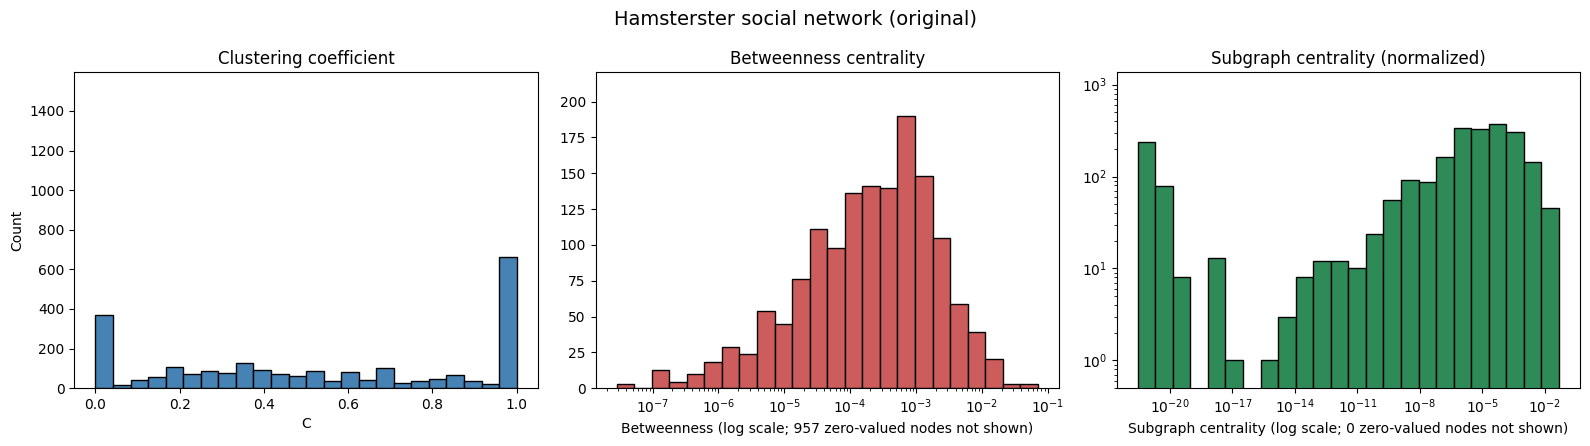

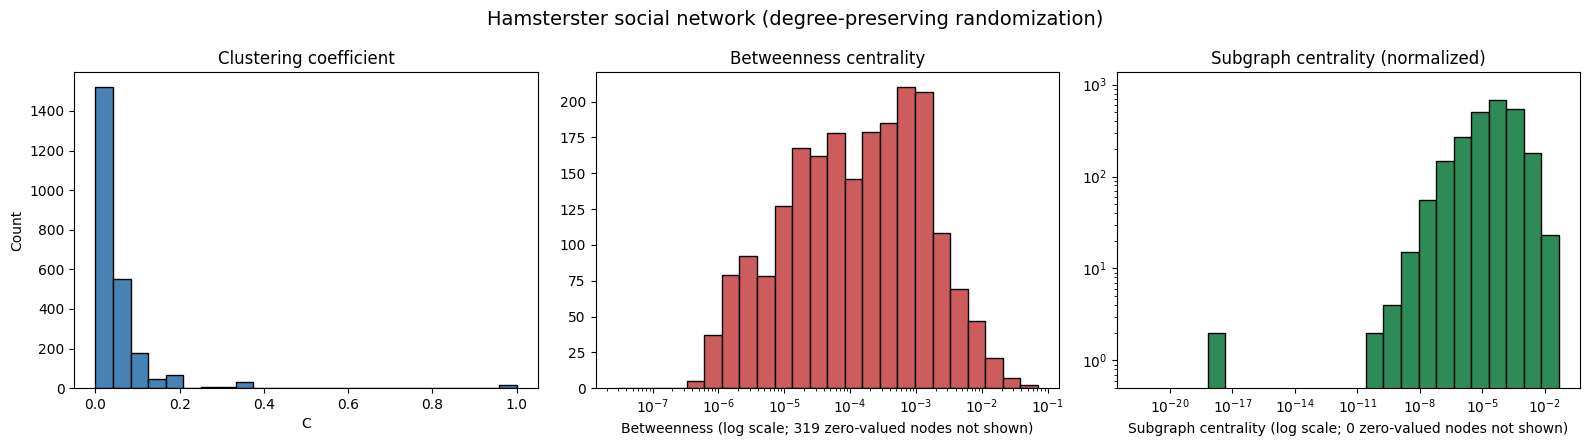


=== Summary: original vs randomized ===
statistic                       original    randomized
mean clustering                   0.5375       0.04668
mean betweenness               0.0007258     0.0008824
max betweenness                   0.0551       0.07086
max norm. subgraph c.            0.04472       0.04639


In [5]:
# 1. LOAD THE NETWORK

G = nx.read_edgelist("soc-hamsterster.edges", comments="%", nodetype=int, data=False)
G = nx.Graph(G)

# The assignment needs N and M, and the null model assumes a simple graph => check for self-loops too.
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}, "
      f"self-loops: {nx.number_of_selfloops(G)}")


# 2. DEGREE-PRESERVING NULL MODEL
# Randomize a COPY so the original stays intact (double_edge_swap works in place).
G_rand = G.copy()

n_edges = G_rand.number_of_edges()
n_swaps = 10 * n_edges
max_tries = 100 * n_swaps

nx.double_edge_swap(G_rand, nswap=n_swaps, max_tries=max_tries, seed=42)
print(f"Requested {n_swaps} swaps (10 x {n_edges} edges)")

# Verify the null model preserves degs. Comparing sorted sequences
# checks the degree distribution; comparing per-node degrees is stricter, and
# double_edge_swap should pass it too because every node keeps its own degree.
orig_deg = sorted(d for _, d in G.degree())
rand_deg = sorted(d for _, d in G_rand.degree())
print("Degree sequences match (sorted)?  ", orig_deg == rand_deg)
print("Per-node degrees identical?       ", dict(G.degree()) == dict(G_rand.degree()))
print("Edge count preserved?             ", G.number_of_edges() == G_rand.number_of_edges())

# How different is the rewired graph from the original? If this fraction is  small, the graph is under-randomized.
shared = sum(1 for u, v in G_rand.edges() if G.has_edge(u, v))
print(f"Fraction of edges still identical to the original: {shared / n_edges:.3f}")



# 3. COMPUTE STATISTICS

def compute_stats(graph):
    """
    Return clustering, betweenness, and normalized subgraph centrality as numpy
    arrays, all in the SAME node order (list(graph.nodes())) so they can be
    compared node by node (e.g. against degree or component membership).
    """
    nodes = list(graph.nodes())
    clust = nx.clustering(graph)
    betw = nx.betweenness_centrality(graph)
    subg = nx.subgraph_centrality(graph, normalized=True)
    return {
        "nodes": nodes,
        "clustering": np.array([clust[n] for n in nodes]),
        "betweenness": np.array([betw[n] for n in nodes]),
        "subgraph": np.array([subg[n] for n in nodes]),
    }

# Compute once and reuse everywhere.
stats = {"orig": compute_stats(G), "rand": compute_stats(G_rand)}
graphs = {"orig": G, "rand": G_rand}


# 4. DIAGNOSTICS:

def diagnostics(name, graph, st):
    nodes = st["nodes"]
    deg = np.array([graph.degree(n) for n in nodes])

    # Connectivity. Small components break normalized subgraph centrality:
    # a node in a small component has local lambda << global lambda_max, so its
    # normalized score is about e^-(lambda_max - lambda_local) veryyyy small?
    comps = sorted(nx.connected_components(graph), key=len, reverse=True)
    giant = comps[0]
    in_giant = np.array([n in giant for n in nodes])

    # Dominant eigenvalue of the adj matrix
    lam1 = np.linalg.eigvalsh(nx.to_numpy_array(graph, nodelist=nodes))[-1]

    # Degree assortativity: > 0 hubs link to hubs, < 0 hubs link to low-degree
    # nodes, ~ 0 no preference. A configuration-model null is near 0
    assort = nx.degree_assortativity_coefficient(graph)

    print(f"\n=== Diagnostics: {name} ===")
    print(f"Components: {len(comps)} | giant component: {len(giant)} nodes "
          f"({len(giant) / len(nodes):.1%})")
    print(f"Largest eigenvalue lambda_1: {lam1:.3f}")
    print(f"Degree assortativity: {assort:.4f}")

    # Betweenness zeros: dropped from the log-axis histogram, so report how many.
    b = st["betweenness"]
    print(f"Betweenness: mean={b.mean():.4g}, max={b.max():.4g}, "
          f"zeros={np.sum(b == 0)} of {len(b)} ({np.mean(b == 0):.1%}) "
          f"-> these are NOT shown in the log histogram")

    # Clustering spikes at 0 and 1: are they just low-degree nodes?
    c = st["clustering"]
    print(f"Clustering: mean={c.mean():.4f}")
    print(f"  C == 0: {np.sum(c == 0)} nodes, of which degree 1: "
          f"{np.sum((c == 0) & (deg == 1))}")
    print(f"  C == 1: {np.sum(c == 1)} nodes, of which degree <= 3: "
          f"{np.sum((c == 1) & (deg <= 3))}")

    # Is the low-score cluster of subgraph centrality just non-giant nodes?
    s = st["subgraph"]
    low = s < 1e-15   # threshold chosen from the gap in the histogram
    print(f"Subgraph centrality: min={s.min():.3g}, max={s.max():.3g}, "
          f"exact zeros={np.sum(s == 0)}")
    print(f"  nodes with SC < 1e-15: {low.sum()}, of which OUTSIDE the giant "
          f"component: {(low & ~in_giant).sum()}")

for name in ("orig", "rand"):
    diagnostics(name, graphs[name], stats[name])


# 5. SHARED BINS
# Build the bins ONCE from the pooled data so both graphs use identical edges.
def pooled_positive(key):
    """Concatenate a statistic over both graphs, keeping only values > 0
    (log bins can't contain zeros)."""
    allv = np.concatenate([stats[k][key] for k in stats])
    return allv[allv > 0]

bc_all, sc_all = pooled_positive("betweenness"), pooled_positive("subgraph")
N_BINS = 25
bins = {
    "clustering": np.linspace(0, 1, N_BINS),   # linear: bounded in [0, 1]
    "betweenness": np.logspace(np.log10(bc_all.min()), np.log10(bc_all.max()), N_BINS),
    "subgraph": np.logspace(np.log10(sc_all.min()), np.log10(sc_all.max()), N_BINS),
}

# Shared y-limits so bar heights are visually comparable across the two figures.
# Compute the histogram counts for both graphs and take the max per panel.
def max_count(key):
    m = 0
    for k in stats:
        v = stats[k][key]
        v = v if key == "clustering" else v[v > 0]
        m = max(m, np.histogram(v, bins=bins[key])[0].max())
    return m

ymax = {k: max_count(k) for k in bins}


# 6. PLOTTING

def plot_three(name, title, fname):
    st = stats[name]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(title, fontsize=14)

    # (1) Clustering coefficient: linear bins on [0, 1]
    axes[0].hist(st["clustering"], bins=bins["clustering"],
                 color="steelblue", edgecolor="k")
    axes[0].set_title("Clustering coefficient")
    axes[0].set_xlabel("C")
    axes[0].set_ylabel("Count")
    axes[0].set_ylim(0, ymax["clustering"] * 1.05)

    # (2) Betweenness: log-spaced bins; zeros can't be drawn on a log axis, =>
    # drop them but REPORT how many in the label.
    b = st["betweenness"]
    n_zero_b = int(np.sum(b == 0))
    axes[1].hist(b[b > 0], bins=bins["betweenness"], color="indianred", edgecolor="k")
    axes[1].set_xscale("log")
    axes[1].set_title("Betweenness centrality")
    axes[1].set_xlabel(f"Betweenness (log scale; {n_zero_b} zero-valued nodes not shown)")
    axes[1].set_ylim(0, ymax["betweenness"] * 1.05)

    # (3) Normalized subgraph centrality: log x. Log y is kept so small groups
    # of nodes remain visible; the shared ylim keeps the two figures comparable.
    s = st["subgraph"]
    n_zero_s = int(np.sum(s == 0))
    axes[2].hist(s[s > 0], bins=bins["subgraph"], color="seagreen", edgecolor="k")
    axes[2].set_xscale("log")
    axes[2].set_yscale("log")
    axes[2].set_title("Subgraph centrality (normalized)")
    axes[2].set_xlabel(f"Subgraph centrality (log scale; {n_zero_s} zero-valued nodes not shown)")
    axes[2].set_ylim(0.5, ymax["subgraph"] * 2)   # bottom 0.5 so count-1 bars show

    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

plot_three("orig", "Hamsterster social network (original)", "hampstersss.png")
plot_three("rand", "Hamsterster social network (degree-preserving randomization)", "randoo.png")




# 7. SIDE-BY-SIDE SUMMARY TABLE

print("\n=== Summary: original vs randomized ===")
print(f"{'statistic':<26}{'original':>14}{'randomized':>14}")
for label, key, fn in [
    ("mean clustering", "clustering", np.mean),
    ("mean betweenness", "betweenness", np.mean),
    ("max betweenness", "betweenness", np.max),
    ("max norm. subgraph c.", "subgraph", np.max),
]:
    print(f"{label:<26}{fn(stats['orig'][key]):>14.4g}{fn(stats['rand'][key]):>14.4g}")